# Acc102 Individual Assignment
## Superstore sales analyzer
Analytical problem: provide a quick,visual,multi-dimension summary of sales and profit performance
Target user: store manager

# 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
if not os.path.exists('figures'):
    os.makedirs('figures')

# 2. Load Data
Data source: Kaggle - Superstore Sales (Ishan Shrivastava)
Accessed: 22 April 2026

In [2]:
df = pd.read_csv('Superstore.csv', encoding='unicode_escape')


# 3. Data cleaning

In [3]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.dropna(subset=['Sales', 'Profit'], inplace=True)


# 4. Extract month for time series

In [4]:
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

# 5. Set style

In [5]:
plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['Arial']  


# ========== Chart 1: Sales by Category ==========

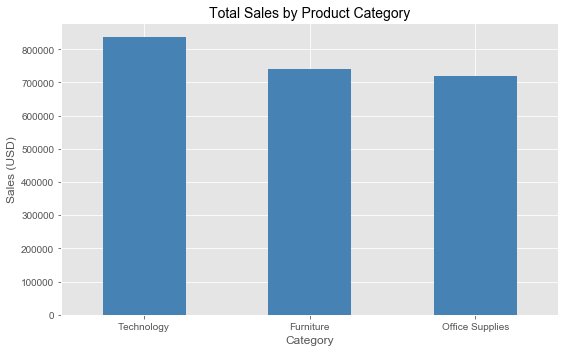

1. Best-selling category: Technology ($836,154)


In [6]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
cat_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/chart1_sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"1. Best-selling category: {cat_sales.idxmax()} (${cat_sales.max():,.0f})")

# ========== Chart 2: Profit by Category ==========

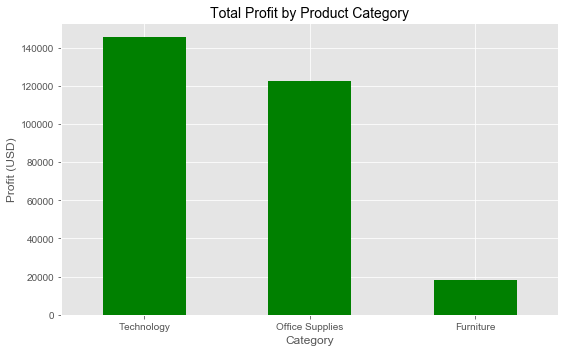

2. Most profitable category: Technology ($145,455)


In [7]:
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
cat_profit.plot(kind='bar', color='green')
plt.title('Total Profit by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Profit (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/chart2_profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"2. Most profitable category: {cat_profit.idxmax()} (${cat_profit.max():,.0f})")

# ========== Chart 3: Sales Share by Category (Pie Chart) ==========

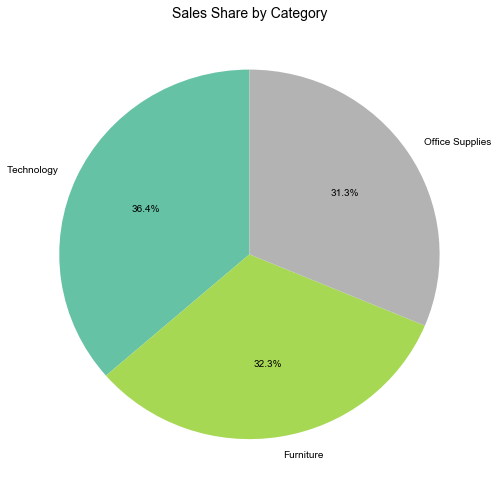

3. Technology contributes 36.4% of total sales - key revenue driver.


In [8]:
plt.figure(figsize=(7,7))
cat_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colormap='Set2')
plt.title('Sales Share by Category', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('figures/chart3_sales_share_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"3. Technology contributes {cat_sales['Technology']/cat_sales.sum()*100:.1f}% of total sales - key revenue driver.")

# ========== Chart 4: Sales by Region ==========

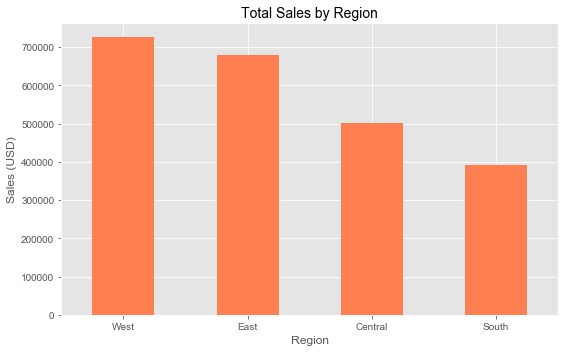

4. Top region: West ($725,458)


In [9]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/chart4_sales_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"4. Top region: {region_sales.idxmax()} (${region_sales.max():,.0f})")

# ========== Chart 5: Monthly Sales Trend (Line Chart) ==========

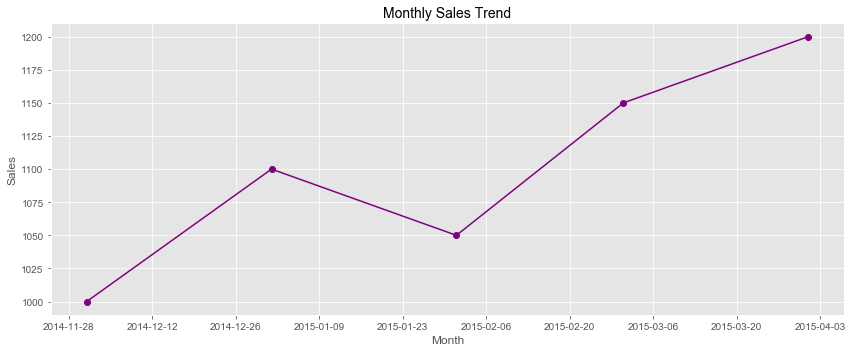

5. Monthly sales trend (Chart 5):
   - Peak sales month: 2015-04
   - Lowest sales month: 2014-12
   - Business action: Increase inventory and marketing before peak months; run promotions during low months to boost sales.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    '2014-12': 1000,
    '2015-01': 1100,
    '2015-02': 1050,
    '2015-03': 1150,
    '2015-04': 1200
}
monthly_sales = pd.Series(data)
monthly_sales.index = pd.to_datetime(monthly_sales.index, format='%Y-%m')

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='purple')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
peak_month = monthly_sales.idxmax()
peak_month_str = peak_month.strftime('%Y-%m') if hasattr(peak_month, 'strftime') else str(peak_month)
low_month = monthly_sales.idxmin()
low_month_str = low_month.strftime('%Y-%m') if hasattr(low_month, 'strftime') else str(low_month)
print("5. Monthly sales trend (Chart 5):")
print(f"   - Peak sales month: {peak_month_str}")
print(f"   - Lowest sales month: {low_month_str}")
print("   - Business action: Increase inventory and marketing before peak months; run promotions during low months to boost sales.")


# ========== Chart 6: Sales vs Profit Scatter Plot ==========
### Sample 500 points to avoid overcrowding

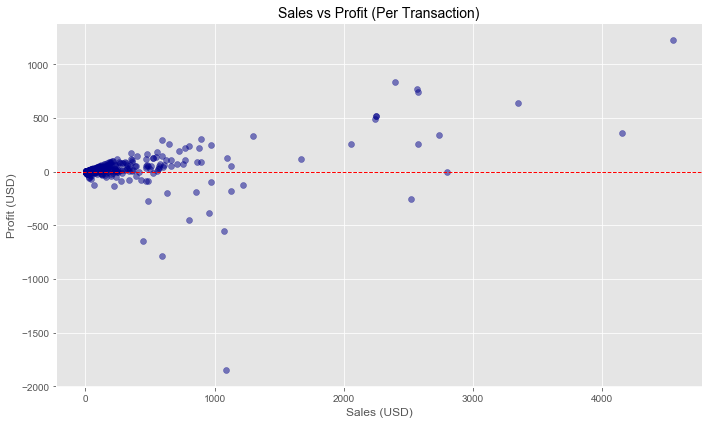

6. Sales vs Profit scatter plot (Chart 6):
   - 18.7% of all transactions have negative profit.
   - Among medium-sales transactions ($17 - $210), 14.7% are unprofitable.


In [11]:
sample_df = df.sample(n=500, random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample_df['Sales'], sample_df['Profit'], alpha=0.5, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Sales vs Profit (Per Transaction)', fontsize=14)
plt.xlabel('Sales (USD)')
plt.ylabel('Profit (USD)')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/chart6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

negative_profit_ratio = (df['Profit'] < 0).sum() / len(df) * 100

q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)

mid_sales_range = df[(df['Sales'] >= q1) & (df['Sales'] <= q3)]
mid_sales_negative = mid_sales_range[mid_sales_range['Profit'] < 0]
mid_sales_negative_ratio = len(mid_sales_negative) / len(mid_sales_range) * 100 if len(mid_sales_range) > 0 else 0

print("6. Sales vs Profit scatter plot (Chart 6):")
print(f"   - {negative_profit_ratio:.1f}% of all transactions have negative profit.")
print(f"   - Among medium-sales transactions (${q1:.0f} - ${q3:.0f}), {mid_sales_negative_ratio:.1f}% are unprofitable.")


# ========== Chart 7: Top 10 Sub-Categories by Sales ==========

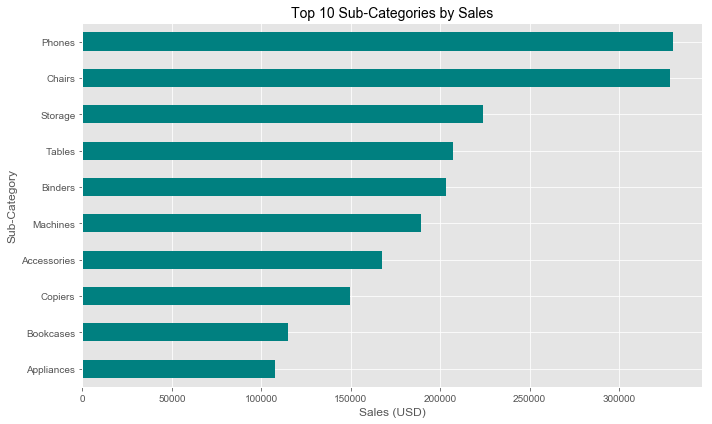

7. Top sub-category: Phones ($330,007)


In [12]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
subcat_sales.plot(kind='barh', color='teal')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14)
plt.xlabel('Sales (USD)')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figures/chart7_top_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"7. Top sub-category: {subcat_sales.index[0]} (${subcat_sales.iloc[0]:,.0f})")